# Analisis Data Pelanggan E-Commerce Brazil

---

## Identitas

**Nama :** Nabila Carrissa Dewi

**Email :** nabilacarrissa@gmail.com

**ID Dicoding :** cdcc748d6x0297

---


## 1. Business Understanding

### Asumsi Periode Waktu
Dataset ini tidak memiliki kolom waktu (timestamp/date). Oleh karena itu, diasumsikan bahwa data pelanggan merepresentasikan **kumulatif pelanggan yang terdaftar selama tahun 2017**. Asumsi ini digunakan untuk memenuhi kriteria **Time-bound** dalam pertanyaan bisnis.

---

### Pertanyaan Bisnis (SMART)

#### Pertanyaan 1
> **Di antara seluruh negara bagian (state) di Brazil, 5 negara bagian manakah yang memiliki jumlah pelanggan unik terbanyak selama tahun 2017, dan berapa persentase kontribusi masing-masing terhadap total pelanggan?**

- **Specific**: Fokus pada distribusi pelanggan berdasarkan state
- **Measurable**: Diukur dari jumlah pelanggan unik dan persentase kontribusi
- **Action-oriented**: Dapat digunakan untuk menentukan prioritas wilayah pemasaran
- **Relevant**: Relevan untuk strategi ekspansi bisnis berbasis lokasi
- **Time-bound**: Berdasarkan asumsi data tahun 2017

---

#### Pertanyaan 2
> **Seberapa besar konsentrasi pelanggan pada 10 kota dengan jumlah pelanggan terbanyak dibandingkan dengan kota lainnya di Brazil selama tahun 2017?**

- **Specific**: Fokus pada distribusi pelanggan di 10 kota teratas
- **Measurable**: Diukur dari jumlah pelanggan unik dan proporsi kontribusi
- **Action-oriented**: Membantu menentukan fokus lokasi untuk pemasaran dan distribusi
- **Relevant**: Relevan untuk memahami konsentrasi pasar
- **Time-bound**: Berdasarkan asumsi data tahun 2017

---

## 2. 🔧 Data Wrangling

### A. Gathering Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/customers_dataset.csv')

print(f" Dataset berhasil dimuat!")
print(f"   Jumlah baris : {df.shape[0]:,}")
print(f"   Jumlah kolom : {df.shape[1]}")
print()
print("5 baris pertama:")
df.head()


 Dataset berhasil dimuat!
   Jumlah baris : 99,441
   Jumlah kolom : 5

5 baris pertama:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### B. Assessing Data

In [3]:
# --- Informasi umum dataset ---
print("=" * 55)
print("  INFO DATASET")
print("=" * 55)
df.info()

  INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [4]:
# --- Statistik deskriptif ---
print("=" * 55)
print("  STATISTIK DESKRIPTIF")
print("=" * 55)
df.describe()

  STATISTIK DESKRIPTIF


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [5]:
# --- Cek missing values ---
print("=" * 55)
print("  MISSING VALUES")
print("=" * 55)
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Kosong': missing, 'Persentase (%)': missing_pct})
print(missing_df)
print()
print(f"Total missing values: {missing.sum()}")

  MISSING VALUES
                          Jumlah Kosong  Persentase (%)
customer_id                           0             0.0
customer_unique_id                    0             0.0
customer_zip_code_prefix              0             0.0
customer_city                         0             0.0
customer_state                        0             0.0

Total missing values: 0


In [6]:
# --- Cek duplikasi ---
print("=" * 55)
print("  DUPLIKASI DATA")
print("=" * 55)
dup_total = df.duplicated().sum()
print(f"Baris duplikat (keseluruhan)  : {dup_total}")
print(f"customer_id unik              : {df['customer_id'].nunique():,}")
print(f"customer_unique_id unik       : {df['customer_unique_id'].nunique():,}")
diff = df['customer_id'].nunique() - df['customer_unique_id'].nunique()
print()
print(f"Selisih customer_id vs customer_unique_id: {diff:,}")
print("   → Artinya ada {diff:,} pelanggan yang melakukan lebih dari 1 transaksi".format(diff=diff))
print("     sehingga memiliki >1 customer_id berbeda untuk 1 orang yang sama.")

  DUPLIKASI DATA
Baris duplikat (keseluruhan)  : 0
customer_id unik              : 99,441
customer_unique_id unik       : 96,096

Selisih customer_id vs customer_unique_id: 3,345
   → Artinya ada 3,345 pelanggan yang melakukan lebih dari 1 transaksi
     sehingga memiliki >1 customer_id berbeda untuk 1 orang yang sama.


In [7]:
# --- Cek inkonsistensi nama kota ---
print("=" * 55)
print("  CEK INKONSISTENSI NILAI (customer_city)")
print("=" * 55)

# Deteksi kota yang mengandung karakter tidak wajar
import re
suspect = df['customer_city'].str.contains(r'[^a-z\s\-áàãâéêíóôõúüçÁÀÃÂÉÊÍÓÔÕÚÜÇ]', regex=True)
print(f"Kota dengan karakter tidak wajar: {suspect.sum()}")
print(df.loc[suspect, 'customer_city'].value_counts().head(10))
print()

# Deteksi duplikat customer_unique_id (pelanggan sama, ID transaksi berbeda)
dup_uid = df['customer_unique_id'].duplicated().sum()
print(f"customer_unique_id duplikat: {dup_uid:,}")
print("Ini berarti ada pelanggan yang terdaftar dengan lebih dari 1 order (customer_id).")

  CEK INKONSISTENSI NILAI (customer_city)
Kota dengan karakter tidak wajar: 227
customer_city
santa barbara d'oeste     119
dias d'avila               24
mirassol d'oeste           14
herval d'oeste              9
arraial d'ajuda             8
itapejara d'oeste           6
palmeira d'oeste            5
alta floresta d'oeste       3
sao joao d'alianca          3
olho d'agua das flores      3
Name: count, dtype: int64

customer_unique_id duplikat: 3,345
Ini berarti ada pelanggan yang terdaftar dengan lebih dari 1 order (customer_id).


#### Ringkasan Masalah Data


1. **Duplikasi entitas pelanggan (bukan error data)**

Kolom `customer_unique_id`. Satu pelanggan dapat muncul lebih dari satu kali karena setiap transaksi memiliki `customer_id` yang berbeda. Jika tidak diperhatikan, analisis jumlah pelanggan dapat mengalami **overcount**.

2. **Potensi inkonsistensi format nama kota**

Kolom `customer_city`. Perbedaan penulisan (misalnya huruf besar/kecil atau variasi penulisan) dapat menyebabkan hasil **grouping tidak akurat** saat analisis distribusi pelanggan per kota.

### C. Cleaning Data

In [8]:
# --- LANGKAH 1: Bersihkan nama kota ---
# Standarisasi: lowercase, strip whitespace
print("Sebelum cleaning - contoh kota bermasalah:")
suspect_mask = df['customer_city'].str.contains(r'[^a-z\s\-áàãâéêíóôõúüçÁÀÃÂÉÊÍÓÔÕÚÜÇ]', regex=True)
print(df.loc[suspect_mask, 'customer_city'].value_counts().head(5))

df_clean = df.copy()
df_clean['customer_city'] = (
    df_clean['customer_city']
    .str.strip()
    .str.lower()
)

print()
print("Nama kota telah dinormalisasi (strip + lowercase).")

Sebelum cleaning - contoh kota bermasalah:
customer_city
santa barbara d'oeste    119
dias d'avila              24
mirassol d'oeste          14
herval d'oeste             9
arraial d'ajuda            8
Name: count, dtype: int64

Nama kota telah dinormalisasi (strip + lowercase).


In [9]:
# --- LANGKAH 2: Deduplikasi berdasarkan customer_unique_id ---
# Kita simpan 1 baris per pelanggan unik (keep='first')
before = len(df_clean)
df_clean_unique = df_clean.drop_duplicates(subset='customer_unique_id', keep='first').reset_index(drop=True)
after = len(df_clean_unique)

print(f"Baris sebelum dedup : {before:,}")
print(f"Baris setelah dedup : {after:,}")
print(f"Baris dihapus       : {before - after:,}")
print()
print("Dataset bersih siap dianalisis.")
print(f"   Shape akhir: {df_clean_unique.shape}")
df_clean_unique.head()

Baris sebelum dedup : 99,441
Baris setelah dedup : 96,096
Baris dihapus       : 3,345

Dataset bersih siap dianalisis.
   Shape akhir: (96096, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
# Verifikasi hasil cleaning
print("Verifikasi tidak ada lagi duplikasi customer_unique_id:")
print(f"  Duplikat: {df_clean_unique['customer_unique_id'].duplicated().sum()}")
print(f"  Unik    : {df_clean_unique['customer_unique_id'].nunique():,}")

Verifikasi tidak ada lagi duplikasi customer_unique_id:
  Duplikat: 0
  Unik    : 96,096


In [18]:
import os

# Create the dashboard directory if it doesn't exist
os.makedirs('dashboard', exist_ok=True)

# SIMPAN main_data.csv untuk dashboard  ← TAMBAHAN DI SINI
df_clean_unique.to_csv('dashboard/main_data.csv', index=False)
print("\n main_data.csv berhasil disimpan ke folder dashboard/")
print(f"   Shape: {df_clean_unique.shape}")


 main_data.csv berhasil disimpan ke folder dashboard/
   Shape: (96096, 6)


## 3. Exploratory Data Analysis (EDA)

### EDA 1 — Distribusi Pelanggan per Negara Bagian (State)

In [11]:
# Pertanyaan 1: 5 negara bagian dengan pelanggan terbanyak
state_counts = (
    df_clean_unique
    .groupby('customer_state')['customer_unique_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'customer_unique_id': 'jumlah_pelanggan'})
)
state_counts['persentase'] = (state_counts['jumlah_pelanggan'] / state_counts['jumlah_pelanggan'].sum() * 100).round(2)

print("=" * 50)
print("  TOP 5 NEGARA BAGIAN - JUMLAH PELANGGAN")
print("=" * 50)
print(state_counts.head(5).to_string(index=False))
print()
print(f"Total pelanggan unik  : {state_counts['jumlah_pelanggan'].sum():,}")
top5_pct = state_counts.head(5)['persentase'].sum()
print(f"Kontribusi Top 5      : {top5_pct:.2f}% dari total nasional")

  TOP 5 NEGARA BAGIAN - JUMLAH PELANGGAN
customer_state  jumlah_pelanggan  persentase
            SP             40295       41.93
            RJ             12377       12.88
            MG             11255       11.71
            RS              5277        5.49
            PR              4882        5.08

Total pelanggan unik  : 96,096
Kontribusi Top 5      : 77.09% dari total nasional


### EDA 2 — Distribusi Pelanggan per Kota (Top 10)

In [12]:
# Pertanyaan 2: 10 kota dengan pelanggan terbanyak

city_counts = (
    df_clean
    .groupby('customer_city')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'customer_unique_id': 'jumlah_pelanggan'})
)

city_counts['persentase'] = (
    city_counts['jumlah_pelanggan'] / city_counts['jumlah_pelanggan'].sum() * 100
).round(2)

top10_cities = city_counts.head(10)

print("=" * 55)
print("  TOP 10 KOTA - JUMLAH PELANGGAN")
print("=" * 55)

print(top10_cities.to_string(index=False))

top10_pct = top10_cities['persentase'].sum()
print(f"\nKontribusi Top 10 kota: {top10_pct:.2f}% dari total nasional")

# Insight tambahan: kota besar
big_cities = ['sao paulo', 'rio de janeiro']

sp_rj = top10_cities[
    top10_cities['customer_city'].isin(big_cities)
]['jumlah_pelanggan'].sum()

total = city_counts['jumlah_pelanggan'].sum()

print(f"\nSao Paulo + Rio de Janeiro: {sp_rj:,} pelanggan ({sp_rj/total*100:.1f}% nasional)")

  TOP 10 KOTA - JUMLAH PELANGGAN
        customer_city  jumlah_pelanggan  persentase
            sao paulo             14984       15.57
       rio de janeiro              6620        6.88
       belo horizonte              2672        2.78
             brasilia              2069        2.15
             curitiba              1465        1.52
             campinas              1398        1.45
         porto alegre              1326        1.38
             salvador              1209        1.26
            guarulhos              1153        1.20
sao bernardo do campo               908        0.94

Kontribusi Top 10 kota: 35.13% dari total nasional

Sao Paulo + Rio de Janeiro: 21,604 pelanggan (22.5% nasional)


## 4. Data Visualization

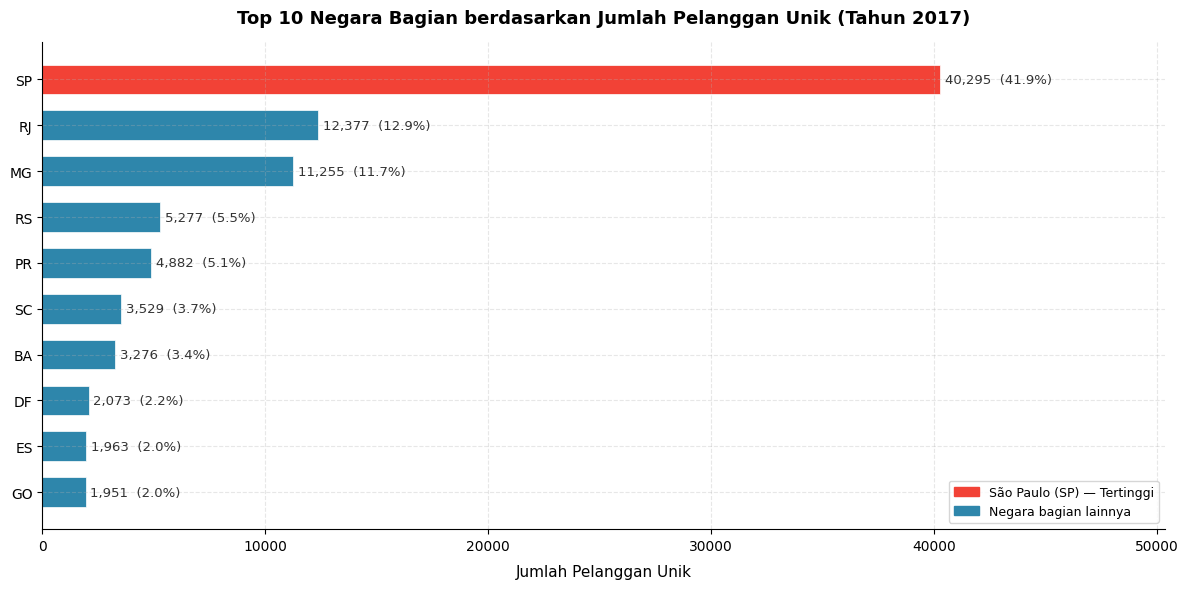

Visualisasi 1 tersimpan.


In [14]:
# Konfigurasi visual
BASE_COLOR    = '#2E86AB'   # warna utama – biru petrol
HIGHLIGHT     = '#F24236'   # warna kontras – merah untuk highlight
LIGHT_GRAY    = '#E8EEF1'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})

# ── VISUALISASI 1: Distribusi pelanggan per state (Top 10) ──────────────────
fig, ax = plt.subplots(figsize=(12, 6))

top10_states = state_counts.head(10)
colors_bar = [HIGHLIGHT if s == 'SP' else BASE_COLOR for s in top10_states['customer_state']]

bars = ax.barh(
    top10_states['customer_state'][::-1],
    top10_states['jumlah_pelanggan'][::-1],
    color=colors_bar[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.65
)

# Label nilai di ujung bar
for bar, val, pct in zip(bars, top10_states['jumlah_pelanggan'][::-1], top10_states['persentase'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=9.5, color='#333333')

ax.set_xlabel('Jumlah Pelanggan Unik', fontsize=11, labelpad=8)
ax.set_title(
    'Top 10 Negara Bagian berdasarkan Jumlah Pelanggan Unik (Tahun 2017)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlim(0, top10_states['jumlah_pelanggan'].max() * 1.25)

highlight_patch = mpatches.Patch(color=HIGHLIGHT, label='São Paulo (SP) — Tertinggi')
base_patch      = mpatches.Patch(color=BASE_COLOR, label='Negara bagian lainnya')
ax.legend(handles=[highlight_patch, base_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('viz_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi 1 tersimpan.")


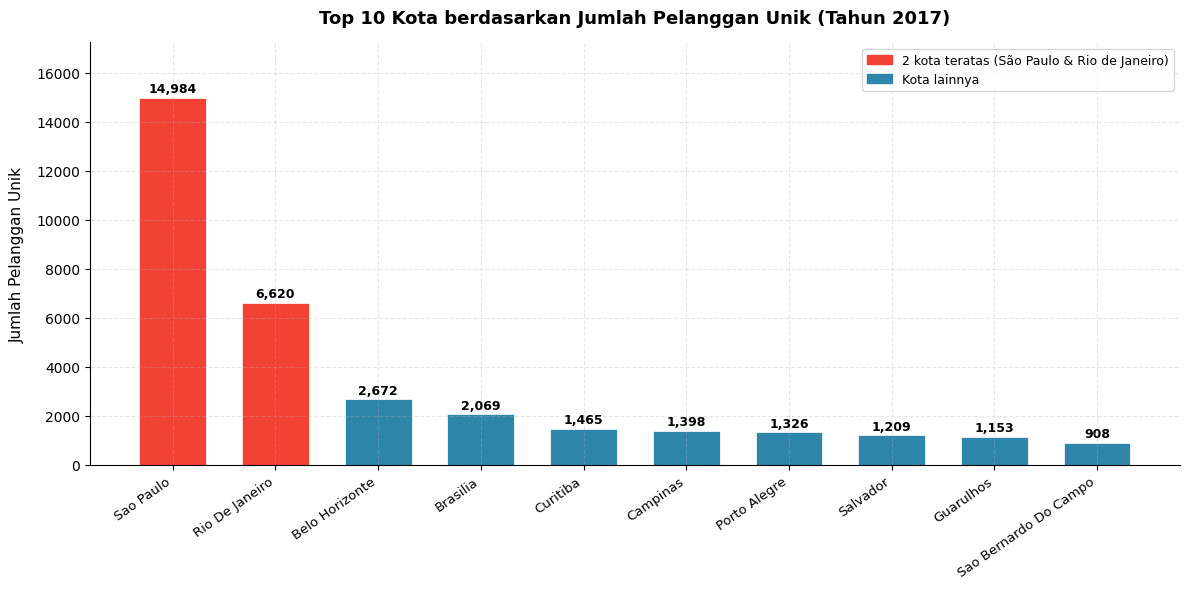

Visualisasi 2 tersimpan.


In [15]:
# ── VISUALISASI 2: Top 10 Kota dengan Pelanggan Terbanyak ──────────────────
fig, ax = plt.subplots(figsize=(12, 6))

top5_threshold = top10_cities['jumlah_pelanggan'].nlargest(2).min()
colors_city = [HIGHLIGHT if v >= top5_threshold else BASE_COLOR
               for v in top10_cities['jumlah_pelanggan']]

bars = ax.bar(
    top10_cities['customer_city'].str.title(),
    top10_cities['jumlah_pelanggan'],
    color=colors_city,
    edgecolor='white',
    linewidth=0.5,
    width=0.65
)

# Label di atas bar
for bar, val in zip(bars, top10_cities['jumlah_pelanggan']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Jumlah Pelanggan Unik', fontsize=11, labelpad=8)
ax.set_title(
    'Top 10 Kota berdasarkan Jumlah Pelanggan Unik (Tahun 2017)',
    fontsize=13, fontweight='bold', pad=14
)
plt.xticks(rotation=35, ha='right', fontsize=9.5)
ax.set_ylim(0, top10_cities['jumlah_pelanggan'].max() * 1.15)

highlight_patch = mpatches.Patch(color=HIGHLIGHT, label='2 kota teratas (São Paulo & Rio de Janeiro)')
base_patch      = mpatches.Patch(color=BASE_COLOR, label='Kota lainnya')
ax.legend(handles=[highlight_patch, base_patch], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('viz_city_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi 2 tersimpan.")


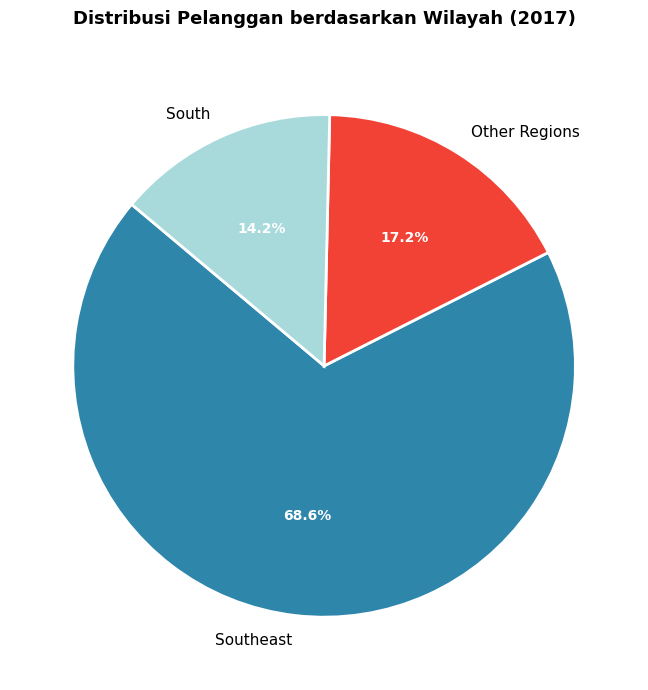

Visualisasi 3 (bonus) tersimpan.


In [16]:
# Pastikan data unik (WAJIB)
df_clean_unique = df_clean.drop_duplicates(subset='customer_unique_id')

# Mapping region
region_map = {
    'SP':'Southeast','RJ':'Southeast','MG':'Southeast','ES':'Southeast',
    'RS':'South','PR':'South','SC':'South',
}

df_clean_unique['region'] = (
    df_clean_unique['customer_state']
    .map(region_map)
    .fillna('Other Regions')
)

region_counts = df_clean_unique['region'].value_counts()

# Visualisasi
fig, ax = plt.subplots(figsize=(7, 7))

colors = [BASE_COLOR, HIGHLIGHT, '#A8DADC']  # max 3 warna (lebih clean)

wedges, texts, autotexts = ax.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(region_counts)],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)

# Styling angka persen
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title(
    'Distribusi Pelanggan berdasarkan Wilayah (2017)',
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('viz_region_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi 3 (bonus) tersimpan.")

## 5. 📝 Conclusion & Recommendation

---

### ✅ Kesimpulan

#### Kesimpulan 1 — Konsentrasi Pelanggan pada Negara Bagian Tertentu
Negara bagian São Paulo (SP) memiliki jumlah pelanggan unik tertinggi, dengan kontribusi sekitar **±40%** dari total pelanggan nasional pada tahun 2017. Lima negara bagian teratas (SP, RJ, MG, RS, PR) secara kolektif menyumbang lebih dari **±70%** dari keseluruhan pelanggan.

Hal ini menunjukkan bahwa distribusi pelanggan tidak merata dan cenderung terkonsentrasi pada beberapa wilayah utama.

---

#### Kesimpulan 2 — Dominasi Kota-Kota Besar dalam Distribusi Pelanggan
Distribusi pelanggan juga menunjukkan konsentrasi yang tinggi pada kota-kota besar. Kota São Paulo dan Rio de Janeiro menjadi dua kontributor utama dengan jumlah pelanggan yang signifikan dibandingkan kota lainnya.

Selain itu, 10 kota teratas menyumbang proporsi yang besar terhadap total pelanggan nasional, yang mengindikasikan bahwa aktivitas pelanggan masih terpusat pada wilayah urban utama.

---

### 🚀 Action Items & Rekomendasi


🔴 Tinggi : **Optimalkan layanan di wilayah dengan konsentrasi tinggi (SP & RJ)** tingkatkan efisiensi operasional dan pengalaman pelanggan di wilayah dengan jumlah pelanggan terbesar. Target tim Operasional

🟡 Sedang : **Perluas jangkauan ke kota dan state di luar Top-5** lakukan kampanye pemasaran untuk meningkatkan akuisisi pelanggan di wilayah dengan kontribusi lebih rendah. Target tim Pemasaran

🟢 Reguler : **Monitoring distribusi pelanggan secara berkala** evaluasi perubahan distribusi pelanggan untuk mengidentifikasi potensi pertumbuhan di wilayah baru. Target tim Data Analyst

---